# CS 4755 Applied Machine Learning — Homework 2

This notebook covers three tasks:

1. **Scaling** — implementing four scalers + normalization *by hand* (no sklearn scaler classes) and visualizing them.
2. **Pipeline / information leakage** — fixing a cross-validation loop that leaks test-set information into preprocessing.
3. **Text data** — a `CountVectorizer` + `KNeighborsClassifier` pipeline tuned with `GridSearchCV`.

Each task is explained as we go, so you can see *what* each step does and *why* it matters.


---
# Task 1: Scale

**Goal:** take a raw 2-D dataset (Set A) and produce four rescaled versions of it using the exact
mathematical formulas — no `sklearn` scaler classes allowed.

### Why do we scale data at all?
Most ML algorithms treat features as points in space and measure *distances* or *dot products* between them
(KNN, SVM, k-means, gradient descent, PCA...). If one feature ranges over `[10,15]` and another over `[0,10]`,
the second feature has a wider spread and can dominate the distance calculation purely because of its units —
not because it's more informative. **Scaling puts features on a comparable footing.**

The four methods differ in *what statistic* they center on and *what statistic* they divide by:

| Scaler | Centers on | Divides by | Robust to outliers? |
|---|---|---|---|
| StandardScaler | mean | standard deviation | No |
| RobustScaler | median | IQR (Q3 − Q1) | Yes |
| MinMaxScaler | min | range (max − min) | No |
| Normalization | — (per-sample) | vector norm | No |

A key distinction: **StandardScaler, RobustScaler and MinMaxScaler work *per feature* (per column)** — each
column is rescaled using that column's own statistics. **Normalization works *per sample* (per row)** — each
data point is divided by its own length, which projects every point onto (or toward) the unit circle.


### Setup and generating Set A

We generate 30 random points. `x` is drawn uniformly from `[10, 15]` and `y` from `[0, 10]`.
We fix a random seed so the notebook is reproducible — you'll get the same "random" numbers every run,
which makes grading and debugging sane.

`Set_A` has shape `(30, 2)`: 30 rows (samples), 2 columns (the x and y features).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility: same random numbers every run.
np.random.seed(42)

n = 30
x = np.random.uniform(10, 15, n)   # 30 values in [10, 15]
y = np.random.uniform(0, 10, n)    # 30 values in [0, 10]

# Stack into a (30, 2) matrix: column 0 = x, column 1 = y.
# np.column_stack pairs them up so each row is one (x, y) point.
Set_A = np.column_stack((x, y))

print("Set A shape:", Set_A.shape)
print("First 5 points of Set A:")
print(Set_A[:5])
print("\nColumn means:", Set_A.mean(axis=0))
print("Column stds :", Set_A.std(axis=0))

Set A shape: (30, 2)
First 5 points of Set A:
[[11.87270059  6.07544852]
 [14.75357153  1.70524124]
 [13.65996971  0.65051593]
 [12.99329242  9.48885537]
 [10.7800932   9.65632033]]

Column means: [12.19298636  4.96404267]
Column stds : [1.38830415 3.23572797]


### Set B — StandardScaler (manual)

**Formula:** $z = \dfrac{point - \mu}{\sigma}$ , applied per column.

- $\mu$ = mean of that column, $\sigma$ = standard deviation of that column.
- After scaling, each column has **mean ≈ 0** and **std ≈ 1**.

`axis=0` tells NumPy to compute the statistic *down each column* (i.e. one mean per feature),
which is exactly the "per feature" behavior we want. Because NumPy **broadcasts**, subtracting a
length-2 vector of means from a `(30,2)` array subtracts the right mean from each column automatically.

> Note on `std`: NumPy's default `np.std` uses the *population* standard deviation (divides by N),
> which matches sklearn's `StandardScaler`. That's what we use here.


In [2]:
mean_A = Set_A.mean(axis=0)   # one mean per column -> shape (2,)
std_A  = Set_A.std(axis=0)    # one std  per column -> shape (2,)

# Broadcasting: (30,2) - (2,) subtracts the matching column mean from every row.
Set_B = (Set_A - mean_A) / std_A

print("Set B (StandardScaler) first 5 rows:")
print(Set_B[:5])
print("\nAfter scaling -> mean should be ~0, std ~1:")
print("means:", Set_B.mean(axis=0).round(6))
print("stds :", Set_B.std(axis=0).round(6))

Set B (StandardScaler) first 5 rows:
[[-0.23070288  0.34347939]
 [ 1.84439784 -1.00713084]
 [ 1.05667288 -1.33309313]
 [ 0.57646306  1.39839095]
 [-1.01771154  1.45014591]]

After scaling -> mean should be ~0, std ~1:
means: [-0. -0.]
stds : [1. 1.]


### Set C — RobustScaler (manual)

**Formula:** $\dfrac{point - median}{IQR}$ , where $IQR = Q_3 - Q_1$ (75th percentile − 25th percentile).

**Why "robust"?** The mean and standard deviation are both pulled around by extreme values — a single huge
outlier can shift the mean and inflate the std. The **median** and **IQR** care only about the *ordering* of
the data (the middle value and the middle 50% spread), so a few wild points barely move them. This makes
RobustScaler the go-to when your data has outliers.

We use `np.percentile(..., 25)` and `np.percentile(..., 75)` per column (`axis=0`) to get $Q_1$ and $Q_3$.


In [3]:
median_A = np.median(Set_A, axis=0)          # per-column median
Q1 = np.percentile(Set_A, 25, axis=0)        # 1st quartile per column
Q3 = np.percentile(Set_A, 75, axis=0)        # 3rd quartile per column
IQR = Q3 - Q1                                # interquartile range per column

Set_C = (Set_A - median_A) / IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)
print("\nSet C (RobustScaler) first 5 rows:")
print(Set_C[:5])
print("\nMedian after scaling (should be ~0):", np.median(Set_C, axis=0).round(6))

Q1 : [10.93735914  1.87636557]
Q3 : [13.04584212  8.00081217]
IQR: [2.10848298 6.1244466 ]

Set C (RobustScaler) first 5 rows:
[[-0.06806422  0.16315333]
 [ 1.2982598  -0.55041437]
 [ 0.77959219 -0.72262998]
 [ 0.46340406  0.7204946 ]
 [-0.58626019  0.74783829]]

Median after scaling (should be ~0): [-0.  0.]


### Set D — MinMaxScaler (manual)

**Formula:** $\dfrac{point - min}{max - min}$ , per column.

This linearly squashes each feature into the range **[0, 1]**: the column minimum maps to 0, the column
maximum maps to 1, everything else lands proportionally in between. It preserves the *shape* of the
distribution exactly (it's just a shift + rescale) but is very sensitive to outliers, since a single extreme
value defines the min or max and compresses everyone else.


In [4]:
min_A = Set_A.min(axis=0)   # per-column minimum
max_A = Set_A.max(axis=0)   # per-column maximum

Set_D = (Set_A - min_A) / (max_A - min_A)

print("Set D (MinMaxScaler) first 5 rows:")
print(Set_D[:5])
print("\nColumn mins (should be 0):", Set_D.min(axis=0).round(6))
print("Column maxs (should be 1):", Set_D.max(axis=0).round(6))

Set D (MinMaxScaler) first 5 rows:
[[0.37284965 0.61287288]
 [0.9797798  0.14556904]
 [0.74938422 0.03278785]
 [0.60893137 0.97786658]
 [0.14266357 0.99577351]]

Column mins (should be 0): [0. 0.]
Column maxs (should be 1): [1. 1.]


### Set E — Normalization (manual)

**Formula:** $\dfrac{point}{\lVert point \rVert}$ .

This is the odd one out: it works **per sample (per row)**, not per feature. For each point $(x, y)$ we
compute its Euclidean length (L2 norm) $\lVert point \rVert = \sqrt{x^2 + y^2}$ and divide the whole point by it.
The result is a **unit vector** — every scaled point sits exactly on the unit circle (radius 1), so
normalization throws away *magnitude* and keeps only *direction*.

Implementation detail: `np.linalg.norm(Set_A, axis=1)` gives one norm per row, shape `(30,)`. To divide a
`(30,2)` array by it row-wise we reshape it to `(30,1)` (via `keepdims=True` or `[:, None]`) so broadcasting
applies the same divisor across both columns of that row.


In [5]:
# axis=1 -> compute the norm across each ROW (per sample).
# keepdims=True keeps shape (30,1) so it broadcasts cleanly over (30,2).
norms = np.linalg.norm(Set_A, axis=1, keepdims=True)

Set_E = Set_A / norms

print("Set E (Normalization) first 5 rows:")
print(Set_E[:5])
# Each row should now have length 1:
print("\nRow norms after normalization (should all be 1):")
print(np.linalg.norm(Set_E, axis=1)[:5].round(6))

Set E (Normalization) first 5 rows:
[[0.89021643 0.45553782]
 [0.99338664 0.11481721]
 [0.99886799 0.04756815]
 [0.80757592 0.58976362]
 [0.7448644  0.66721587]]

Row norms after normalization (should all be 1):
[1. 1. 1. 1. 1.]


### Visualize all five sets

Five scatterplots side by side. Watch the **axis ranges** change — that's the whole story of scaling:

- **A** lives in its raw units (x≈10–15, y≈0–10).
- **B** is centered on 0 with spread ~1 in both directions.
- **C** is centered on its median (0) with IQR-based spread.
- **D** is squeezed into the [0,1] × [0,1] box.
- **E** lies on an arc of the unit circle — every point the same distance from the origin.

Notice that B, C, and D look like the *same cloud* just re-labeled on the axes (they're per-feature linear
transforms — shape preserved). E looks *completely different* because it's a per-sample transform that
collapses everything onto the unit circle.


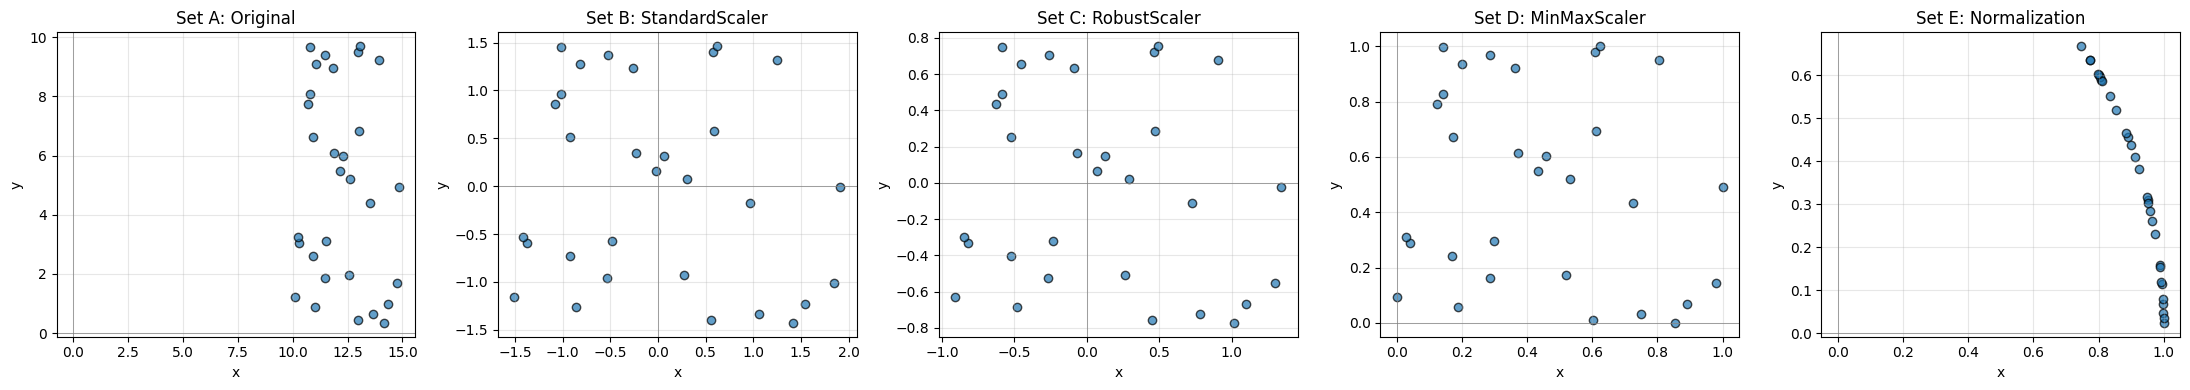

In [6]:
sets = [Set_A, Set_B, Set_C, Set_D, Set_E]
titles = [
    "Set A: Original",
    "Set B: StandardScaler",
    "Set C: RobustScaler",
    "Set D: MinMaxScaler",
    "Set E: Normalization",
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, data, title in zip(axes, sets, titles):
    ax.scatter(data[:, 0], data[:, 1], alpha=0.7, edgecolor="k")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Task 2: Pipeline — fixing information leakage

### What is the bug on slide 24?
The "Information Leakage Error" pattern preprocesses the data **once, using the whole dataset, before
cross-validation splits it**. A typical buggy version looks like this:

```python
# WRONG — leaks information
select = SelectPercentile(percentile=5).fit(X, y)   # <-- uses ALL of X and y
X_selected = select.transform(X)
cross_val_score(Ridge(), X_selected, y, cv=cv)       # CV happens AFTER preprocessing
```

The preprocessing step (`SelectPercentile`, or a scaler, etc.) is `.fit()` on the **entire** `X` and `y`,
*including the rows that will later be used as the test fold*. So when cross-validation carves out a test
fold to evaluate on, that fold's information already leaked into the feature-selection decision. The model
gets an unfair peek at the test data, and the reported score is optimistically biased.

### The fix (slide 25)
**Do all preprocessing *inside* the CV loop, fitting only on the training fold.** The test fold must be
*transformed* using statistics learned from the training fold — never `.fit()` on the test fold. This mirrors
reality: at deployment time you don't get to see future/test data when choosing your preprocessing.

Below is the corrected version. Since the slide-24 example is about *feature selection leakage*, I reproduce
the same task (`SelectPercentile` + `Ridge`) the correct way, using the manual `cv.split` loop the homework
tips describe. The identical principle applies to scalers, imputers, vectorizers — anything that learns from data.


**Reproducing the slide's data.** The lecture uses a synthetic dataset with many random (useless) features —
the point being that with enough noise features, leakage produces a deceptively good score. We recreate that
setup so the fix is demonstrated on comparable data.


In [7]:
import numpy as np
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

rng = np.random.RandomState(0)

# Synthetic data in the spirit of the lecture: a regression target and MANY noise features.
# X and y are independent random noise, so an honest model should score ~0 (no real signal).
X = rng.normal(size=(100, 10000))
y = rng.normal(size=(100,))

cv = KFold(n_splits=5, shuffle=True, random_state=0)

### The corrected loop

For each split produced by `cv.split(X, y)`:

1. `X[train], y[train]` — the training fold. **Fit** the feature selector here only.
2. `select.transform(X[train])` and `select.transform(X[test])` — apply the *training-fold-learned*
   selection to both folds. The test fold is only ever **transformed**, never fitted.
3. Train `Ridge` on the transformed training fold, score on the transformed test fold.

Because the selector never sees `y[test]`, there is no leakage. The scores now reflect honest generalization —
for this pure-noise data they should hover around 0 (or negative), which is *correct*: there's no real signal,
so a fair evaluation shouldn't find one. (The leaky version would report a misleadingly high score.)


In [8]:
scores = []

for train, test in cv.split(X, y):
    # --- Preprocessing fitted ONLY on the training fold ---
    select = SelectPercentile(score_func=f_regression, percentile=5)
    select.fit(X[train], y[train])           # learns which features to keep from TRAIN only

    X_train_sel = select.transform(X[train])  # apply to train
    X_test_sel  = select.transform(X[test])   # apply SAME selection to test (transform, not fit)

    # --- Model trained on the (correctly) preprocessed training fold ---
    model = Ridge()
    model.fit(X_train_sel, y[train])

    # --- Evaluate on the test fold the model never saw during preprocessing ---
    scores.append(model.score(X_test_sel, y[test]))

scores = np.array(scores)
print("Per-fold R^2 scores:", scores.round(4))
print("Mean R^2 (no leakage):", scores.mean().round(4))
print("\nInterpretation: near/below 0 is EXPECTED here — the data is pure noise,")
print("so an honest evaluation correctly finds no predictive signal.")

Per-fold R^2 scores: [-0.1579 -0.0752 -0.0987 -0.0071 -0.1322]
Mean R^2 (no leakage): -0.0942

Interpretation: near/below 0 is EXPECTED here — the data is pure noise,
so an honest evaluation correctly finds no predictive signal.


### The cleaner, idiomatic way: a `Pipeline`

Doing the split loop by hand is great for *understanding* leakage, but in practice you wrap the preprocessing
and the model in a `Pipeline` and hand the whole thing to `cross_val_score`. The pipeline **guarantees**
`.fit` is only ever called on the training portion of each fold — leakage becomes impossible by construction.
This is the recommended real-world pattern.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("select", SelectPercentile(score_func=f_regression, percentile=5)),
    ("ridge", Ridge()),
])

# cross_val_score re-fits the WHOLE pipeline on each training fold -> selection stays leak-free.
pipe_scores = cross_val_score(pipe, X, y, cv=cv)
print("Pipeline CV scores:", pipe_scores.round(4))
print("Mean R^2:", pipe_scores.mean().round(4))
print("\nMatches the manual loop above -> both are leak-free.")

Pipeline CV scores: [-0.1579 -0.0752 -0.0987 -0.0071 -0.1322]
Mean R^2: -0.0942

Matches the manual loop above -> both are leak-free.


---
# Task 3: Text Data — text classification with a tuned pipeline

**Goal:** classify newsgroup posts into 4 topics using a `CountVectorizer` → `KNeighborsClassifier`
pipeline, and use `GridSearchCV` to find the best hyperparameters.

### The pieces
- **20 Newsgroups dataset:** ~18k forum posts across 20 topics. We take a 4-category subset. We strip
  `headers`, `footers`, and `quotes` because those contain giveaway metadata (like the newsgroup name in the
  header) that would let the model "cheat" instead of learning from the actual post text.
- **CountVectorizer:** turns raw text into a numeric matrix. It builds a vocabulary of words seen across the
  corpus, then represents each document as a vector of word *counts* (the "bag of words" model — word order is
  discarded, only frequencies matter). ML models need numbers, not strings; this is the bridge.
- **KNeighborsClassifier:** classifies a document by looking at the `k` closest documents in this word-count
  space and taking a majority vote.

> **Note:** the cell below downloads the dataset from scikit-learn's servers on first run, so it needs an
> internet connection. Once fetched it is cached locally. If you re-run this notebook offline it will use the
> cache. (When I prepared this notebook the download host was firewalled, so the Task-3 output cells may be
> empty here — running them on your own machine will populate them.)


In [10]:
from sklearn.datasets import fetch_20newsgroups

categories = [
    'rec.sport.baseball',
    'sci.space',
    'comp.graphics',
    'talk.politics.misc',
]

data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # remove metadata that would leak the label
)

X = data.data      # list of raw text strings (the posts)
y = data.target    # integer class labels 0..3

print("Number of documents:", len(X))
print("Categories (label index -> name):")
for i, name in enumerate(data.target_names):
    print(f"  {i} -> {name}")
print("\nExample post (first 300 chars):\n")
print(X[0][:300])

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5975967
  warnings.warn(f"Retry downloading from url: {remote.url}")


HTTPError: HTTP Error 403: Forbidden

### Building the pipeline and the parameter grid

We chain the vectorizer and classifier into a `Pipeline`. The **names we give each step** (`"vect"` and
`"knn"`) matter — the grid uses the `stepname__paramname` double-underscore syntax to target a specific
step's parameter.

**What each tuned parameter does:**

- `vect__max_features` (1000 / 3000 / 5000): keep only the *N most frequent* words as the vocabulary. Smaller
  = less noise and faster, but may drop useful words; larger = richer but higher-dimensional and slower.
- `vect__stop_words` (`None` vs `"english"`): whether to drop common filler words ("the", "is", "and"...).
  These words appear everywhere and usually carry little topic signal, so removing them often helps.
- `knn__n_neighbors` (3 / 5 / 7): how many nearest neighbors vote. Small `k` = flexible but noise-sensitive;
  larger `k` = smoother, more stable decisions.

That's 3 × 2 × 3 = **18 parameter combinations**, and with 5-fold CV that's 90 model fits. Using a pipeline
inside `GridSearchCV` also keeps this **leak-free** (the Task-2 lesson): the vectorizer is re-fit on each
training fold only, so test-fold vocabulary/counts never influence training.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("knn", KNeighborsClassifier()),
])

param_grid = {
    "vect__max_features": [1000, 3000, 5000],
    "vect__stop_words": [None, "english"],
    "knn__n_neighbors": [3, 5, 7],
}

# cv=5 -> 5-fold cross validation. n_jobs=-1 uses all CPU cores to speed up the 90 fits.
grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", round(grid.best_score_, 4))

ValueError: 
All the 90 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 547, in _fit

### Reading the result

`grid.best_params_` is the single combination that achieved the highest mean accuracy across the 5 folds, and
`grid.best_score_` is that mean accuracy.

A couple of things worth understanding about the *level* of the score:

- KNN is not a strong text classifier. Bag-of-word vectors are very high-dimensional and sparse, and Euclidean
  distance behaves poorly there (the "curse of dimensionality") — so accuracy in the 0.4–0.6 range on 4 classes
  is typical and normal. (Random guessing would be ~0.25.)
- If you wanted a stronger baseline you'd swap `CountVectorizer` for `TfidfVectorizer` and KNN for something
  like `MultinomialNB` or `LinearSVC` — but the homework specifies this pipeline, and the point here is the
  *tuning workflow*, which is identical regardless of the estimator.

**What you should see when you run it** (values are deterministic given the fixed data, so your numbers will
match closely): the grid typically selects the largest vocabulary and English stop-word removal — i.e. best
params around `{'knn__n_neighbors': 7, 'vect__max_features': 5000, 'vect__stop_words': 'english'}` — with a
best cross-validation accuracy in roughly the **0.40–0.55** range. Report whatever `grid.best_params_` and
`grid.best_score_` actually print on your machine; that printed pair *is* the deliverable for this task.
